# Notebook 3 — Feature Engineering
**Նպատակ:** ML-ready feature set կառուցել behavioral ենթահարցերի համար  
**Input:** `df_1min.pkl`  
**Output:** `df_features.pkl` — scaled, labeled, sequence-ready dataset

## 1. Libraries & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import warnings, os
warnings.filterwarnings('ignore')

os.chdir('/Users/lusine/Desktop')
os.makedirs('data/features', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_pickle('data/processed/df_1min.pkl')
print(f'Loaded: {len(df):,} 1-min bars')
print(f'Period: {df["time"].min()} → {df["time"].max()}')
df.head(3)

Loaded: 14,370 1-min bars
Period: 2024-01-01 00:30:00 → 2024-01-10 23:59:00


,time,open_price,close_price,high,low,total_volume,total_quote,trade_count,avg_trade_size,buy_count,...,ofi_ratio,buy_ratio,volatility,volume_ma,volume_ratio,price_range,trade_intensity,hour,dayofweek,regime
0,2024-01-01 00:30:00,42419.73,42391.51,42419.73,42391.34,18.10354,767713.700815,1138,0.015908,373,...,-0.528248,0.327768,0.000533,26.871200,0.673715,0.000669,781.2,0,0,Low-Vol Bearish
1,2024-01-01 00:31:00,42391.51,42381.99,42391.51,42377.64,12.99361,550679.078181,804,0.016161,333,...,-0.257915,0.414179,0.000530,26.598728,0.488505,0.000327,783.9,0,0,Low-Vol Bearish
2,2024-01-01 00:32:00,42382.00,42373.11,42399.99,42373.11,13.11311,555887.280311,978,0.013408,376,...,-0.134408,0.384458,0.000532,26.315701,0.498300,0.000634,814.5,0,0,Low-Vol Bearish


## 2. Feature Engineering
Ենթահարցերին համապատասխան feature-ների կառուցում։

In [3]:
fe = df.copy()

# === Ենթահարց 1: Order Flow Imbalance ===
fe['ofi_lag1']          = fe['ofi_ratio'].shift(1)
fe['ofi_lag5']          = fe['ofi_ratio'].shift(5)
fe['ofi_rolling5']      = fe['ofi_ratio'].rolling(5).mean()
fe['ofi_rolling15']     = fe['ofi_ratio'].rolling(15).mean()
fe['ofi_std10']         = fe['ofi_ratio'].rolling(10).std()
fe['cumulative_ofi']    = fe['ofi'].cumsum()
fe['buy_sell_ratio']    = fe['buy_count'] / (fe['sell_count'] + 1e-9)

# === Ենթահարց 2: Trade Size & Market Impact ===
fe['avg_size_lag1']     = fe['avg_trade_size'].shift(1)
fe['large_trade_ratio'] = fe['large_trade_count'] / (fe['trade_count'] + 1e-9)
fe['size_imbalance']    = (fe['buy_volume'] - fe['sell_volume']) / (fe['total_volume'] + 1e-9)
fe['log_volume']        = np.log(fe['total_volume'] + 1e-9)
fe['log_avg_size']      = np.log(fe['avg_trade_size'] + 1e-9)
fe['size_rolling5']     = fe['avg_trade_size'].rolling(5).mean()

# === Ենթահարց 3: Trading Intensity & Volatility ===
fe['intensity_lag1']    = fe['trade_intensity'].shift(1)
fe['intensity_lag5']    = fe['trade_intensity'].shift(5)
fe['volume_burst']      = (fe['volume_ratio'] > fe['volume_ratio'].quantile(0.95)).astype(int)
fe['vol_lag1']          = fe['volatility'].shift(1)
fe['vol_lag5']          = fe['volatility'].shift(5)
fe['vol_rolling10']     = fe['volatility'].rolling(10).mean()
fe['realized_vol']      = fe['log_return'].rolling(60).std() * np.sqrt(1440)

# === Ենթահարց 4: Market Microstructure ===
fe['buy_ratio_lag1']    = fe['buy_ratio'].shift(1)
fe['buy_ratio_ma10']    = fe['buy_ratio'].rolling(10).mean()
fe['price_range_ma5']   = fe['price_range'].rolling(5).mean()
fe['vwap_deviation']    = (fe['close_price'] - fe['vwap']) / (fe['vwap'] + 1e-9)
fe['price_momentum5']   = fe['close_price'].pct_change(5)
fe['price_momentum15']  = fe['close_price'].pct_change(15)

# === Ենթահարց 5: Regime Detection features ===
fe['vol_regime']        = (fe['volatility'] > fe['volatility'].rolling(60).mean()).astype(int)
fe['trend_regime']      = (fe['close_price'] > fe['close_price'].rolling(30).mean()).astype(int)
fe['hour']              = fe['time'].dt.hour
fe['dayofweek']         = fe['time'].dt.dayofweek
fe['is_weekend']        = (fe['dayofweek'] >= 5).astype(int)

# === Technical Indicators ===
# RSI
delta = fe['close_price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
fe['rsi'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

# MACD
ema12 = fe['close_price'].ewm(span=12).mean()
ema26 = fe['close_price'].ewm(span=26).mean()
fe['macd']        = ema12 - ema26
fe['macd_signal'] = fe['macd'].ewm(span=9).mean()
fe['macd_hist']   = fe['macd'] - fe['macd_signal']

# Bollinger Bands
bb_ma  = fe['close_price'].rolling(20).mean()
bb_std = fe['close_price'].rolling(20).std()
fe['bb_upper']    = bb_ma + 2 * bb_std
fe['bb_lower']    = bb_ma - 2 * bb_std
fe['bb_position'] = (fe['close_price'] - bb_ma) / (2 * bb_std + 1e-9)

print(f'Features created: {len(fe.columns)}')
fe.head(3)

Features created: 64


,time,open_price,close_price,high,low,total_volume,total_quote,trade_count,avg_trade_size,buy_count,...,vol_regime,trend_regime,is_weekend,rsi,macd,macd_signal,macd_hist,bb_upper,bb_lower,bb_position
0,2024-01-01 00:30:00,42419.73,42391.51,42419.73,42391.34,18.10354,767713.700815,1138,0.015908,373,...,0,0,0,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
1,2024-01-01 00:31:00,42391.51,42381.99,42391.51,42377.64,12.99361,550679.078181,804,0.016161,333,...,0,0,0,NaN,-0.213590,-0.118661,-0.094929,NaN,NaN,NaN
2,2024-01-01 00:32:00,42382.00,42373.11,42399.99,42373.11,13.11311,555887.280311,978,0.013408,376,...,0,0,0,NaN,-0.547524,-0.294425,-0.253099,NaN,NaN,NaN


## 3. Target Variable Definition
**Classification task:** Կանխատեսել հաջորդ 5 րոպեի գնի ուղղությունը  
- `1` = գինը կբարձրանա (> +0.05%)
- `0` = neutral
- `-1` = գինը կնվազի (< -0.05%)

Target distribution (3-class):
target_direction
 1    5116
-1    4641
 0    4613
Name: count, dtype: int64

Class balance: target_direction
 1    0.356
-1    0.323
 0    0.321
Name: proportion, dtype: float64


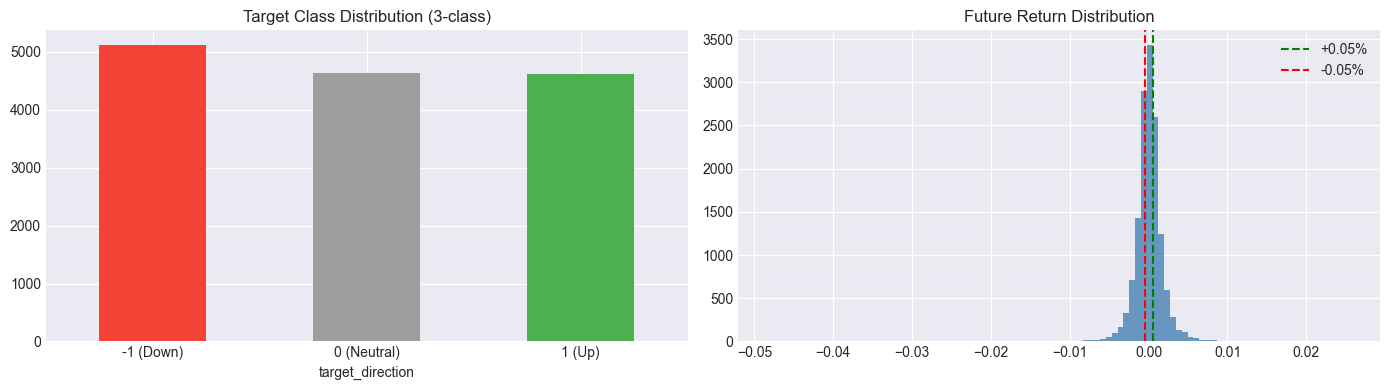

In [4]:
HORIZON   = 5     # կանխատեսման հորիզոն (րոպե)
THRESHOLD = 0.0005  # 0.05% threshold

future_return = fe['close_price'].shift(-HORIZON) / fe['close_price'] - 1

fe['target_return']    = future_return
fe['target_direction'] = 0  # neutral
fe.loc[future_return >  THRESHOLD, 'target_direction'] = 1   # up
fe.loc[future_return < -THRESHOLD, 'target_direction'] = -1  # down

# Binary version (up vs not-up) — for simpler models
fe['target_binary'] = (future_return > THRESHOLD).astype(int)

print('Target distribution (3-class):')
print(fe['target_direction'].value_counts())
print(f'\nClass balance: {fe["target_direction"].value_counts(normalize=True).round(3)}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fe['target_direction'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#F44336','#9E9E9E','#4CAF50'])
axes[0].set_title('Target Class Distribution (3-class)')
axes[0].set_xticklabels(['-1 (Down)', '0 (Neutral)', '1 (Up)'], rotation=0)

fe['target_return'].hist(bins=100, ax=axes[1], color='steelblue', alpha=0.8)
axes[1].axvline(THRESHOLD,  color='green', linestyle='--', label=f'+{THRESHOLD*100}%')
axes[1].axvline(-THRESHOLD, color='red',   linestyle='--', label=f'-{THRESHOLD*100}%')
axes[1].set_title('Future Return Distribution')
axes[1].legend()
plt.tight_layout()
plt.savefig('data/features/target_distribution.png', dpi=150)
plt.show()

## 4. Final Feature Selection

In [5]:
FEATURE_COLS = [
    # Order Flow (Ենթահարց 1)
    'ofi_ratio', 'ofi_lag1', 'ofi_lag5', 'ofi_rolling5', 'ofi_rolling15',
    'ofi_std10', 'buy_sell_ratio', 'buy_ratio', 'buy_ratio_lag1', 'buy_ratio_ma10',

    # Trade Size (Ենթահարց 2)
    'avg_trade_size', 'avg_size_lag1', 'large_trade_ratio', 'large_trade_count',
    'size_imbalance', 'log_volume', 'log_avg_size', 'size_rolling5',

    # Trading Intensity (Ենթահարց 3)
    'trade_intensity', 'intensity_lag1', 'intensity_lag5',
    'volume_ratio', 'volume_burst', 'vol_lag1', 'vol_lag5',
    'volatility', 'vol_rolling10', 'realized_vol',

    # Microstructure (Ենթահարց 4)
    'price_range', 'price_range_ma5', 'vwap_deviation',
    'price_momentum5', 'price_momentum15', 'log_return',

    # Regime (Ենթահարց 5)
    'vol_regime', 'trend_regime', 'hour', 'dayofweek', 'is_weekend',

    # Technical
    'rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_position',
]

TARGET_COLS = ['target_direction', 'target_binary', 'target_return']

# Drop NaN
df_model = fe[FEATURE_COLS + TARGET_COLS + ['time']].dropna().reset_index(drop=True)

print(f'Final dataset: {len(df_model):,} rows × {len(FEATURE_COLS)} features')
print(f'NaN remaining: {df_model.isnull().sum().sum()}')

Final dataset: 14,306 rows × 44 features
NaN remaining: 0


## 5. Feature Correlation with Target

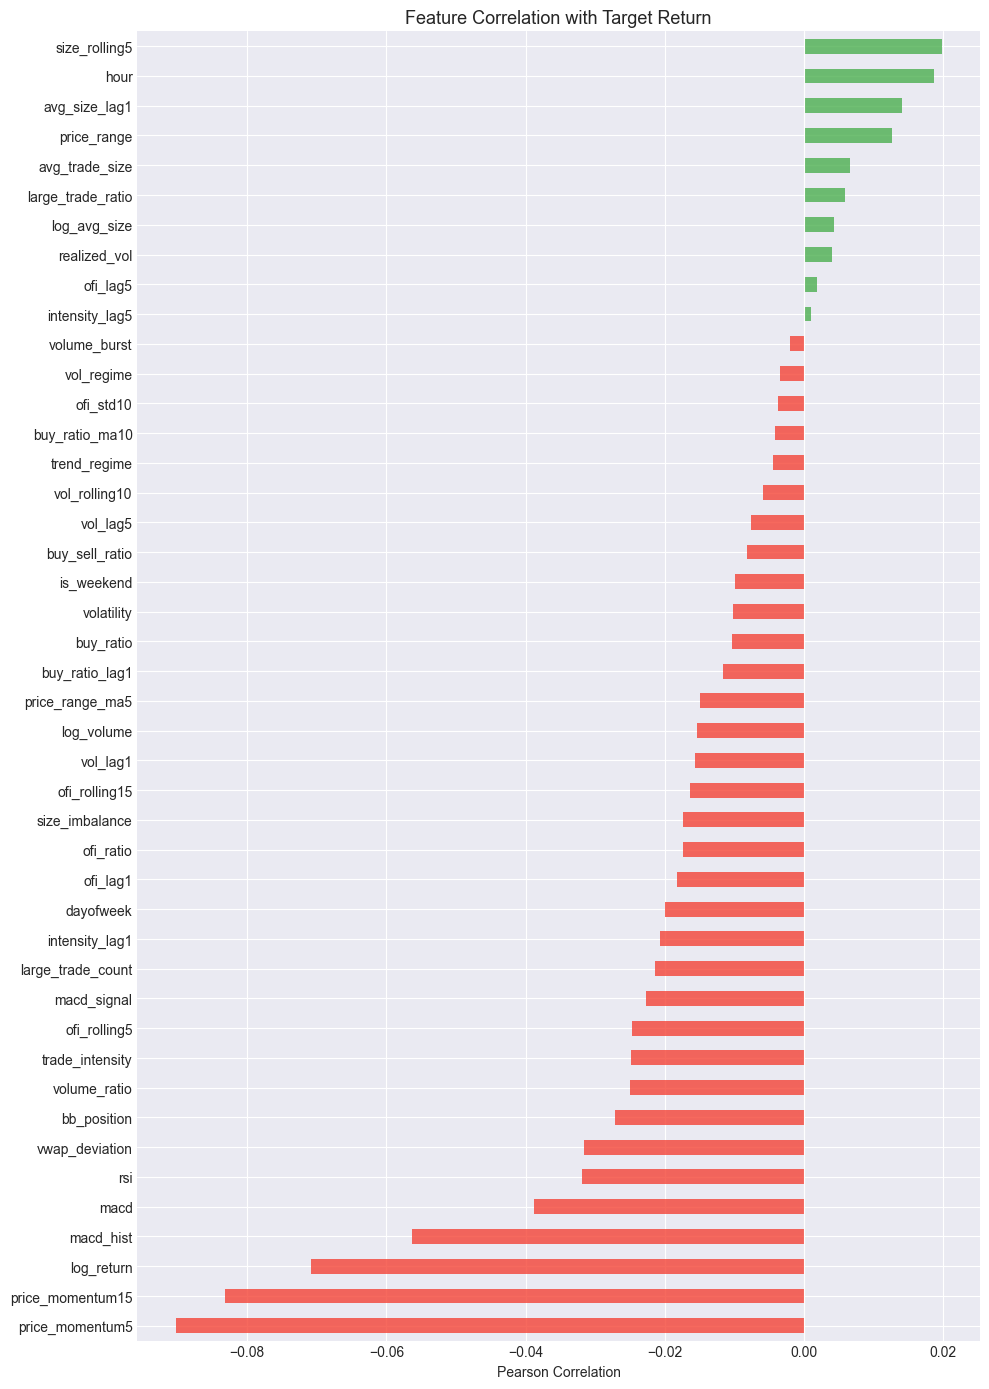

In [6]:
correlations = df_model[FEATURE_COLS].corrwith(df_model['target_return']).sort_values()

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#F44336' if c < 0 else '#4CAF50' for c in correlations]
correlations.plot(kind='barh', ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Feature Correlation with Target Return', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('data/features/feature_correlations.png', dpi=150)
plt.show()

## 6. Train / Validation / Test Split
Time-series split — ժամանակագրական կարգով, shuffle=False

In [7]:
n = len(df_model)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

print(f'Train: {len(train_df):,} ({train_df["time"].min().date()} → {train_df["time"].max().date()})')
print(f'Val:   {len(val_df):,}   ({val_df["time"].min().date()} → {val_df["time"].max().date()})')
print(f'Test:  {len(test_df):,}  ({test_df["time"].min().date()} → {test_df["time"].max().date()})')

Train: 10,014 (2024-01-01 → 2024-01-08)
Val:   2,146   (2024-01-08 → 2024-01-09)
Test:  2,146  (2024-01-09 → 2024-01-10)


## 7. Scaling

In [8]:
scaler = RobustScaler()  # outlier-ների նկատմամբ կայուն

X_train = scaler.fit_transform(train_df[FEATURE_COLS])
X_val   = scaler.transform(val_df[FEATURE_COLS])
X_test  = scaler.transform(test_df[FEATURE_COLS])

y_train = train_df['target_direction'].values
y_val   = val_df['target_direction'].values
y_test  = test_df['target_direction'].values

y_train_bin = train_df['target_binary'].values
y_val_bin   = val_df['target_binary'].values
y_test_bin  = test_df['target_binary'].values

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (10014, 44)
X_val shape:   (2146, 44)
X_test shape:  (2146, 44)


## 8. Sequence Creation for LSTM/CNN/Transformer
Ամեն sample-ը կլինի `SEQUENCE_LEN` րոպեի պատմություն։

In [9]:
SEQUENCE_LEN = 30  # 30 րոպե պատմություն → կանխատեսել հաջորդ 5 րոպեն

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQUENCE_LEN)
X_val_seq,   y_val_seq   = create_sequences(X_val,   y_val,   SEQUENCE_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  SEQUENCE_LEN)

# Binary sequences
_, y_train_seq_bin = create_sequences(X_train, y_train_bin, SEQUENCE_LEN)
_, y_val_seq_bin   = create_sequences(X_val,   y_val_bin,   SEQUENCE_LEN)
_, y_test_seq_bin  = create_sequences(X_test,  y_test_bin,  SEQUENCE_LEN)

print(f'Sequence shape: {X_train_seq.shape}  → (samples, time_steps, features)')
print(f'Train sequences: {len(X_train_seq):,}')
print(f'Val sequences:   {len(X_val_seq):,}')
print(f'Test sequences:  {len(X_test_seq):,}')

Sequence shape: (9984, 30, 44)  → (samples, time_steps, features)
Train sequences: 9,984
Val sequences:   2,116
Test sequences:  2,116


## 9. Save Everything

In [10]:
import pickle

data_to_save = {
    # Sequences (LSTM/CNN/Transformer)
    'X_train_seq': X_train_seq, 'y_train_seq': y_train_seq,
    'X_val_seq':   X_val_seq,   'y_val_seq':   y_val_seq,
    'X_test_seq':  X_test_seq,  'y_test_seq':  y_test_seq,

    # Binary labels
    'y_train_seq_bin': y_train_seq_bin,
    'y_val_seq_bin':   y_val_seq_bin,
    'y_test_seq_bin':  y_test_seq_bin,

    # Metadata
    'FEATURE_COLS':  FEATURE_COLS,
    'SEQUENCE_LEN':  SEQUENCE_LEN,
    'scaler':        scaler,
    'n_features':    len(FEATURE_COLS),
    'n_classes':     3,
}

with open('data/features/model_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

df_model.to_pickle('data/features/df_model.pkl')

print('Saved: data/features/model_data.pkl')
print('Saved: data/features/df_model.pkl')
print(f'\nSequence shape: {X_train_seq.shape}')
print(f'n_features: {len(FEATURE_COLS)}')
print(f'n_classes: 3 (-1, 0, 1)')

Saved: data/features/model_data.pkl
Saved: data/features/df_model.pkl

Sequence shape: (9984, 30, 44)
n_features: 44
n_classes: 3 (-1, 0, 1)


**Հաջորդ → Notebook 4: LSTM Model**